### get data

In [17]:
import pandas as pd
import numpy as np
import talib.abstract as ta
import mplfinance as mpf

In [18]:
import ccxt

exchange = ccxt.binanceusdm({
	'apiKey': '',
	'secret': '',
})
# turn on dfnet
# hasattr(exchange, 'set_sandbox_mode')
exchange.set_sandbox_mode(True)

In [19]:
df = pd.DataFrame(exchange.fetch_ohlcv(symbol='ETHUSDT', timeframe='1h', limit= 1000))
df.columns = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
df.Date= pd.to_datetime(df.Date, unit='ms')
# 定义价格异常的条件，例如价格为负数或超出合理范围
price_columns = ['Open', 'High', 'Low', 'Close']
for col in price_columns:
    df[col] = df[col].mask((df[col] <= 0) | (df[col] > df[col].quantile(0.999)), np.nan)
    df[col] = df[col].ffill()

### processing

In [35]:
def calculate_exhaustion_score(price_series, accel_smooth=5, vol_window=21, score_window=10):
    """
    Calculates a professional-grade Trend Exhaustion Score.

    Args:
        price_series (pd.Series): The series of asset prices.
        accel_smooth (int): Smoothing period for the acceleration signal (EMA span).
        vol_window (int): Lookback window for volatility normalization (rolling std).
        score_window (int): Lookback window for accumulating the score (rolling sum).

    Returns:
        pd.Series: The final Trend Exhaustion Score.
    """
    log_return = np.log(price_series / price_series.shift(1))
    raw_acceleration = log_return.diff()

    smoothed_acceleration = raw_acceleration.ewm(span=accel_smooth, adjust=False).mean()

    # 用收益率的标准差作为 normalizer
    return_volatility = log_return.rolling(window=vol_window).std()
    # 加上一个很小的数(epsilon)防止除以零
    epsilon = 1e-9
    normalized_acceleration = smoothed_acceleration / (return_volatility + epsilon)

    exhaustion_score = normalized_acceleration.rolling(window=score_window).sum()
    
    return exhaustion_score

In [20]:
def calculate_exhaustion_score_robust(price_series, accel_smooth=5, vol_window=21, score_window=8, long_vol_window= 252):
    """
    Calculates a professional-grade and numerically stable Trend Exhaustion Score.

    Args:
        price_series (pd.Series): The series of asset prices.
        accel_smooth (int): Smoothing period for the acceleration signal (EMA span).
        vol_window (int): Lookback window for volatility normalization (rolling std).
        score_window (int): Lookback window for accumulating the score (rolling sum).
        long_vol_window (int): A longer window to establish a baseline volatility for the floor.

    Returns:
        pd.Series: The final, stable Trend Exhaustion Score.
    """
    log_return = np.log(price_series / price_series.shift(1))
    raw_acceleration = log_return.diff()

    smoothed_acceleration = raw_acceleration.ewm(span=accel_smooth, adjust=False).mean()

    # --- 【核心修正】 ---
    # 1. 计算短期的、可能不稳定的波动率
    return_volatility = log_return.rolling(window=vol_window).std()

    # 2. 计算一个长期的、更稳定的基准波动率，并以此设定一个动态的“地板”
    #    我们取长期波动率均值的10%作为下限，这是一个合理的起点
    volatility_floor = return_volatility.rolling(window=long_vol_window).mean().mean() * 0.1
    epsilon = 1e-9 # 仍然保留epsilon以防万一
    
    # 3. 使用 .clip() 方法，确保波动率不会低于我们设定的地板值 + epsilon
    stable_volatility = return_volatility.clip(lower=volatility_floor) + epsilon
    
    # 4. 使用稳定后的波动率进行标准化
    normalized_acceleration = smoothed_acceleration / stable_volatility
    # --- 【修正结束】 ---

    # (可选) 为了进一步增强稳健性，可以对标准化后的结果也进行clip，防止极端情况
    normalized_acceleration = normalized_acceleration.clip(-10, 10)

    exhaustion_score = normalized_acceleration.rolling(window=score_window).sum()
    
    return exhaustion_score

In [21]:
df['raw_acceleration'] = np.log(df['Close'] / df['Close'].shift(1)).diff()
df['exhaustion_score'] = calculate_exhaustion_score_robust(df['Close'])
df['exhaustion_score'].describe()

count    972.000000
mean      -0.008156
std        0.612317
min       -2.170932
25%       -0.384644
50%       -0.006396
75%        0.381114
max        2.121561
Name: exhaustion_score, dtype: float64

### visualization

In [ ]:
# calc BIAS_percentile indicator
def BIAS_percentile_origin(dataframe:pd.DataFrame, baseline_period= 144, percentile_window= 377):
    dataframe['tp'] = (dataframe['High'] + dataframe['Low'] + dataframe['Close']) / 3
    dataframe['MA_144'] = ta.MA(dataframe['tp'], timeperiod=baseline_period)
    dataframe['BIAS'] = (dataframe['tp'] - dataframe['MA_144']) / dataframe['MA_144'] * 100
    dataframe['BIAS_percentile'] = dataframe['BIAS'].rolling(window=percentile_window).apply(
        lambda x: (x.rank(pct=True)).iloc[-1] * 100 if len(x) == percentile_window else np.nan
    )
    return dataframe

In [22]:
# calc BIAS_percentile indicator
def rolling_percentile(arr) -> float:
    ranks = np.argsort(np.argsort(arr))
    return ranks[-1] / (len(arr) - 1) * 100

def BIAS_percentile(dataframe:pd.DataFrame, baseline_period= 144, percentile_window= 377):
    dataframe['tp'] = (dataframe['High'] + dataframe['Low'] + dataframe['Close']) / 3
    dataframe['MA_144'] = ta.MA(dataframe['tp'], timeperiod=baseline_period)
    bias = (dataframe['tp'] - dataframe['MA_144']) / dataframe['MA_144'] * 100

    percentile_rank = bias.rolling(window= 377).apply(rolling_percentile, raw=True)
    return percentile_rank

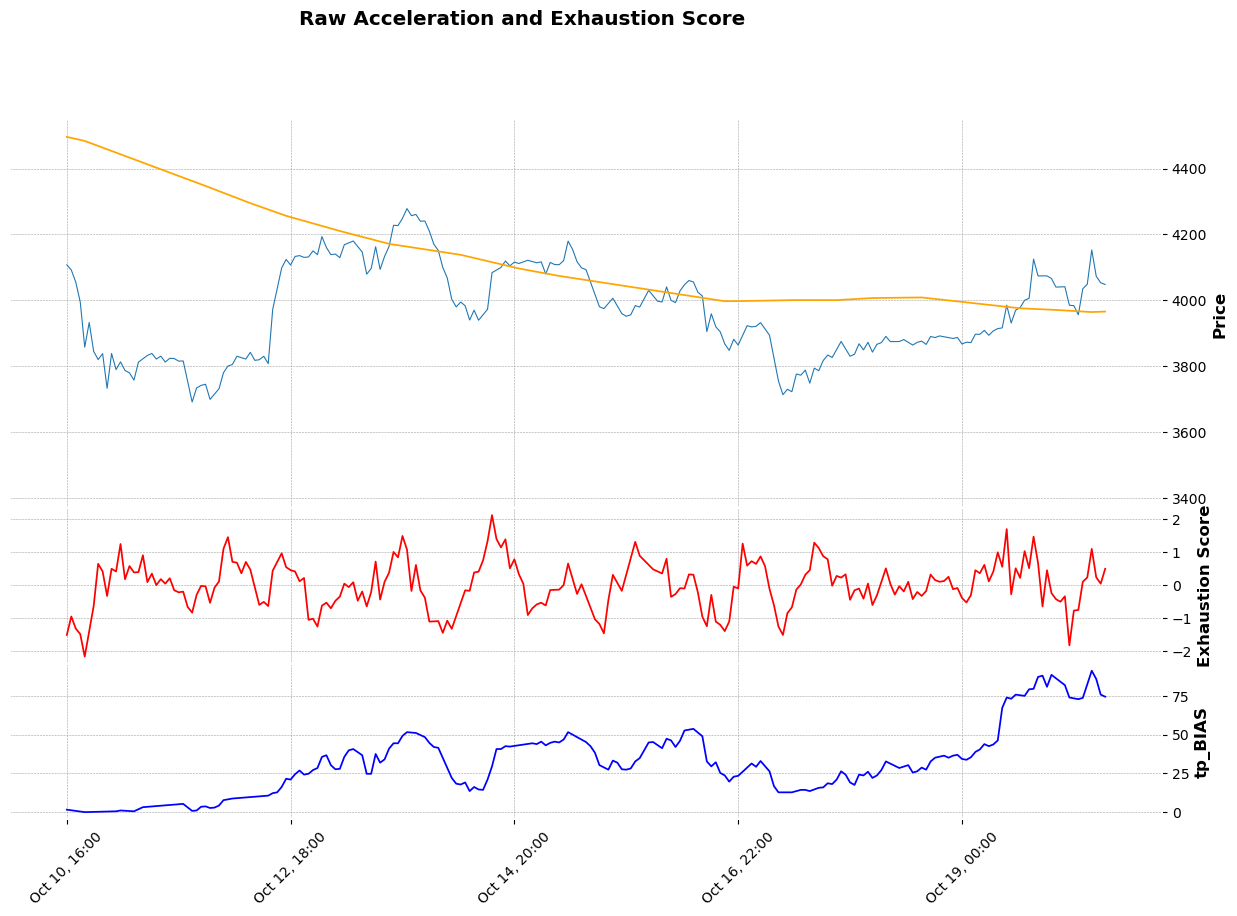

In [23]:
# calculate the acceleration of returns
# --- 对比原始因子和优化后的因子 ---
# Calculate the raw acceleration and exhaustion score
vdf = df.copy()
# vdf = BIAS_percentile(vdf)
vdf['BIAS_percentile'] = BIAS_percentile(vdf)
# vdf['raw_acceleration'] = np.log(vdf['Close'] / vdf['Close'].shift(1)).diff()
vdf['exhaustion_score'] = calculate_exhaustion_score_robust(vdf['Close'])
vdf = vdf.tail(233).copy()

# Plot the two series using mplfinance
mpf.plot(
    vdf.set_index('Date'),
    type='line',
    style='charles',
    addplot=[
        # mpf.make_addplot(vdf['raw_acceleration'], panel=1, color='blue', ylabel='Raw Acceleration'),
        mpf.make_addplot(vdf['exhaustion_score'], panel=1, color='red', ylabel='Exhaustion Score'),
        # add BIAS_percentile 
        mpf.make_addplot(vdf['BIAS_percentile'], panel=2, color='blue', ylabel='tp_BIAS'),
        # add MA144
        mpf.make_addplot(vdf['MA_144'], color='orange', ylabel='MA144')
    ],
    figsize=(16, 10),
    title="Raw Acceleration and Exhaustion Score"
)


# # --- 打印结果，观察区别 ---
# # 你会发现 raw_acceleration 上下跳动非常剧烈，几乎没有可读性
# # 而 exhaustion_score 则平滑得多，并且能清晰地指示出趋势动能的累积性变化
# print("Comparing raw acceleration vs. professional exhaustion score:")
# print(df[['price', 'raw_acceleration', 'exhaustion_score']].tail(20).round(4))

### use 

#### continue

In [30]:
def generate_reversal_signals(df, percentile_window=377, low_percentile=10, high_percentile=90):
    """
    Generates reversal signals based on the exhaustion score reversing from extreme zones.
    """
    score = df['exhaustion_score']
    df['BIAS_percentile'] = BIAS_percentile(df)
    
    # 1. 定义动态的极端区域阈值
    # low_threshold = score.rolling(window=percentile_window).quantile(low_percentile / 100)
    # high_threshold = score.rolling(window=percentile_window).quantile(high_percentile / 100)
    
    # 2. 识别分数是否在极端区域内
    # in_oversold_zone = score < low_threshold
    # in_overbought_zone = score > high_threshold
    # percentile_rank = score.rolling(window=percentile_window).apply(lambda x: x.rank(pct=True).iloc[-1] * 100, raw=False)
    percentile_rank = score.rolling(window= percentile_window).apply(rolling_percentile, raw=True)
    
    # 3. 识别分数本身是否开始反转 (方法一)
    score_reversing_up = (score > score.shift(1)) & (score.shift(1) < score.shift(2))
    score_reversing_down = (score < score.shift(1)) & (score.shift(1) > score.shift(2))

    # 4. 结合逻辑：当分数在极端区域内 *并且* 刚刚发生反转时，生成信号
    # 我们用 shift(1) 是为了在反转发生后的下一根K线才发出信号，符合实盘逻辑
    # buy_signal = in_oversold_zone.shift(1) & score_reversing_up
    # buy_signal = (percentile_rank < 10).shift(1) & score_reversing_up & (df['BIAS_percentile'] < 20).shift(1)
    buy_signal = score_reversing_up & (df['BIAS_percentile'] < 20).shift(1)
    # sell_signal = in_overbought_zone.shift(1) & score_reversing_down 
    # sell_signal = (percentile_rank > 90).shift(1) & score_reversing_down & (df['BIAS_percentile'] > 80).shift(1)
    sell_signal = score_reversing_down & (df['BIAS_percentile'] > 80).shift(1)

    
    # 将信号转换为 -1, 1, 0
    signals = pd.Series(np.nan, index=df.index)
    signals[buy_signal] = 1
    signals[sell_signal] = -1
    
    return signals

In [31]:
df['signals'] = generate_reversal_signals(df)
signals = df['signals'].dropna()

In [32]:
# return the idx where signals == -1
s = signals[signals == 1].index
s

Index([736, 743, 748, 755, 758, 761, 767, 772, 777, 779, 781, 783, 786, 788,
       790, 793, 796, 800, 807, 811, 813, 858, 928, 939, 943],
      dtype='int64')

In [33]:
df.tail(11)

,Date,Open,High,Low,Close,Volume,raw_acceleration,exhaustion_score,tp,MA_144,BIAS_percentile,signals
989,2025-10-19 22:00:00,4040.04,4249.99,4040.03,4041.11,269.511,0.006682,-0.505911,4110.376667,3969.636782,84.042553,NaN
990,2025-10-19 23:00:00,4041.12,4221.65,4041.11,4041.11,240.706,-0.000265,-0.340369,4101.290000,3968.601759,81.914894,NaN
991,2025-10-20 00:00:00,4041.12,4195.00,3980.00,3984.95,2814.329,-0.013995,-1.830122,4053.316667,3967.283519,73.936170,-1.0
992,2025-10-20 01:00:00,3985.01,4147.00,3972.02,3983.65,937.696,0.013668,-0.775912,4034.223333,3966.009907,73.138298,NaN
993,2025-10-20 02:00:00,3983.66,4162.59,3954.65,3956.09,1488.614,-0.006616,-0.755953,4024.443333,3964.910764,72.872340,NaN
994,2025-10-20 03:00:00,3998.99,4111.00,3953.17,4035.00,1807.632,0.026692,0.099498,4033.056667,3964.075139,73.670213,NaN
995,2025-10-20 04:00:00,4100.99,4190.00,4035.00,4048.71,3706.865,-0.016358,0.230079,4091.236667,3963.911968,82.446809,NaN
996,2025-10-20 05:00:00,4184.00,4190.00,4044.00,4152.90,2952.647,0.022017,1.098232,4128.966667,3964.235602,91.223404,NaN
997,2025-10-20 06:00:00,4152.90,4173.00,4071.40,4073.06,107693.077,-0.044821,0.235154,4105.820000,3964.828333,85.904255,-1.0
998,2025-10-20 07:00:00,4073.06,4073.73,4052.01,4053.17,111322.546,0.014517,0.042421,4059.636667,3965.298727,75.797872,NaN


In [34]:
pdf = df.set_index('Date')[['Open', 'High', 'Low', 'Close', 'MA_144', 'BIAS_percentile', 'exhaustion_score', 'signals']].tail(233).copy()
pdf.tail(100)

,Open,High,Low,Close,MA_144,BIAS_percentile,exhaustion_score,signals
Date,,,,,,,,
2025-10-16 05:00:00,3996.86,4018.49,3981.36,3994.88,4022.348356,41.223404,0.351434,NaN
2025-10-16 06:00:00,3994.87,4044.00,3994.03,4040.65,4020.166782,47.340426,0.798512,NaN
2025-10-16 07:00:00,4041.00,4042.96,3994.45,4000.00,4018.015926,46.276596,-0.358130,NaN
2025-10-16 08:00:00,3998.64,4004.40,3982.81,3992.78,4015.643125,42.021277,-0.274129,NaN
2025-10-16 09:00:00,3992.78,4039.90,3944.67,4028.56,4013.391481,46.010638,-0.095021,NaN
...,...,...,...,...,...,...,...,...
2025-10-20 04:00:00,4100.99,4190.00,4035.00,4048.71,3963.911968,82.446809,0.230079,NaN
2025-10-20 05:00:00,4184.00,4190.00,4044.00,4152.90,3964.235602,91.223404,1.098232,NaN
2025-10-20 06:00:00,4152.90,4173.00,4071.40,4073.06,3964.828333,85.904255,0.235154,-1.0


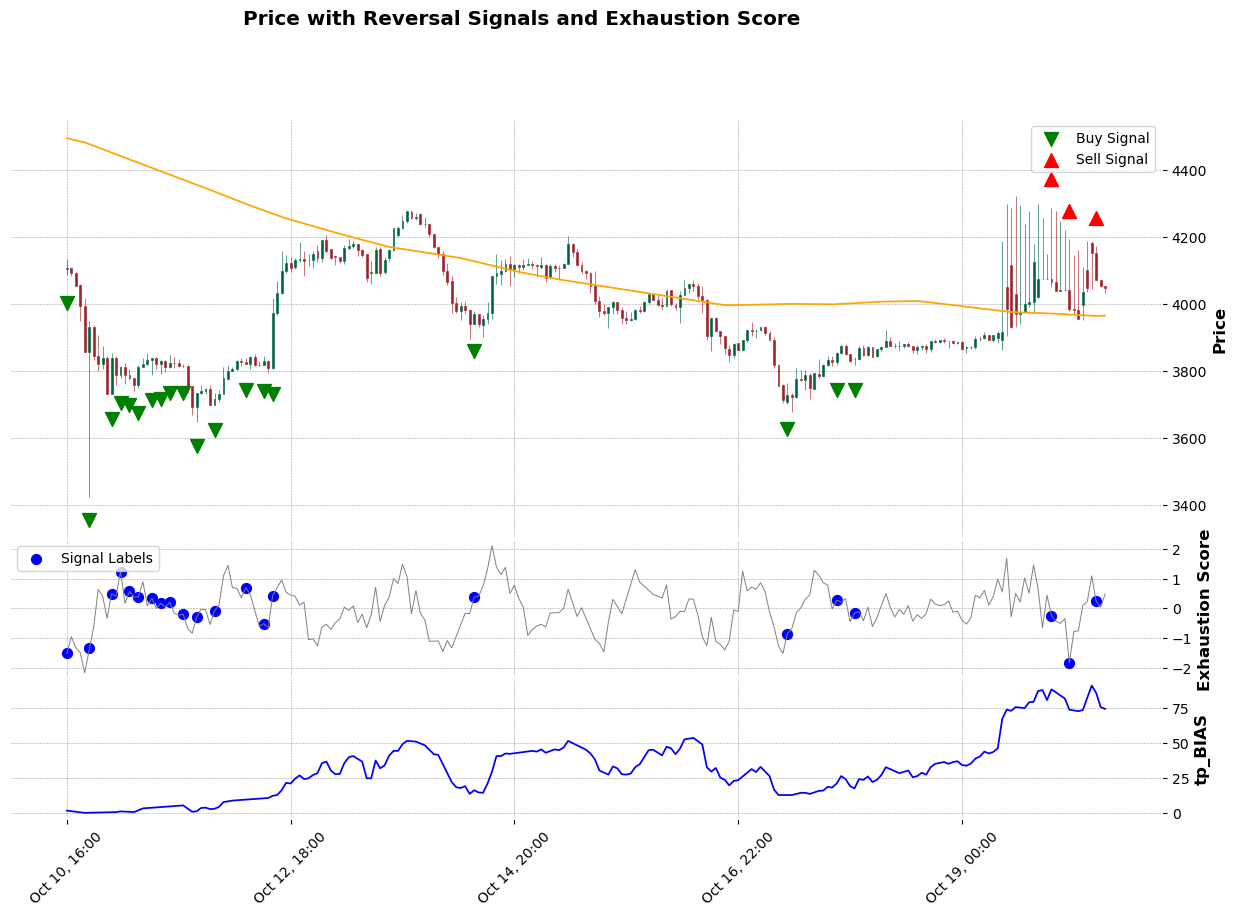

In [35]:
# visualization of signals
# use mpf to visualize the signals by labels on the subplot
# locate the signals
# pdf = df.set_index('Date')[['Open', 'High', 'Low', 'Close', 'exhaustion_score', 'signals']].tail(500).copy()

bull = np.where(
    pdf['signals'] == 1,
    pdf['Low'] * 0.98,
    np.nan
)
bear = np.where(
    pdf['signals'] == -1,
    pdf['High'] * 1.02,
    np.nan
)
subplot_labels = np.where(
    (pdf['signals'].notna()),
    pdf['exhaustion_score'],
    np.nan
)

# plotting
ap = [
    # subplot for exhaustion_score
    mpf.make_addplot(pdf['exhaustion_score'], panel=1, color='gray', width= 0.7, ylabel='Exhaustion Score'),
    # add MA144
    mpf.make_addplot(pdf['MA_144'], color='orange', ylabel='MA144', secondary_y=False),
    # subplot for signals
    mpf.make_addplot(subplot_labels, type='scatter', markersize=50, marker='o', color='blue', panel=1, secondary_y=False, label='Signal Labels'),
    # main chart for buy/sell signals
    mpf.make_addplot(bull, type='scatter', markersize=100, marker='v', color='green', panel=0, secondary_y=False, label='Buy Signal'),
    mpf.make_addplot(bear, type='scatter', markersize=100, marker='^', color='red', panel=0, secondary_y=False, label='Sell Signal'),
    # add BIAS_percentile 
    mpf.make_addplot(pdf['BIAS_percentile'], panel=2, color='blue', ylabel='tp_BIAS', secondary_y=False)
]

mpf.plot(
    pdf,
    type='candle',
    style='charles',
    addplot=ap,
    figsize=(16, 10),
    title="Price with Reversal Signals and Exhaustion Score",
    panel_ratios=(3, 1, 1),
    # datetime_format='%Y-%m-%d %H:%M:%S'
)

    
 

In [26]:
pdf.tail(100)

,Open,High,Low,Close,MA_144,BIAS_percentile,exhaustion_score,signals
Date,,,,,,,,
2025-09-28 08:00:00,4012.96,4014.74,3984.73,3991.20,4353.566042,4.509284,-0.341656,NaN
2025-09-28 12:00:00,3989.00,4030.00,3956.00,4019.47,4351.044144,5.570292,0.056275,NaN
2025-09-28 16:00:00,4017.72,4047.22,3990.73,4037.43,4349.010417,6.631300,0.245756,NaN
2025-09-28 20:00:00,4035.33,4188.80,4000.00,4140.40,4347.464560,9.549072,0.779550,NaN
2025-09-29 00:00:00,4137.05,4143.00,4096.94,4116.57,4345.850787,10.079576,0.489895,NaN
...,...,...,...,...,...,...,...,...
2025-10-14 04:00:00,4151.30,4157.61,3972.96,3979.88,4245.653981,14.323607,-1.377217,NaN
2025-10-14 08:00:00,3979.50,4009.75,3895.06,3969.93,4242.375162,10.875332,-0.903602,1.0
2025-10-14 12:00:00,3970.32,4083.93,3903.21,4083.82,4238.745324,14.323607,-0.275467,NaN


### find peak and trough ADVANCED METHOD

In [ ]:
def generate_robust_reversal_signals_final(df, prominence_threshold=1.5):
    """
    Generates robust reversal signals using a causal, real-time prominence logic.
    This is the final, production-ready version.
    """
    score = df['exhaustion_score']

    # --- 疑问一的最终解决方案 ---
    # 1. 在t时刻，判断t-1是否为峰/谷
    is_peak_at_t_minus_1 = (score.shift(1) > score.shift(2)) & (score.shift(1) > score)
    is_trough_at_t_minus_1 = (score.shift(1) < score.shift(2)) & (score.shift(1) < score)

    # 2. 提取t-1时刻的峰/谷值
    peak_values = score.shift(1).where(is_peak_at_t_minus_1)
    trough_values = score.shift(1).where(is_trough_at_t_minus_1)

    # 3. 获得历史上最近的峰/谷值
    last_peak = peak_values.ffill()
    last_trough = trough_values.ffill()

    # --- 疑问二的最终解决方案 ---
    # 4. 计算从最近峰/谷的回落/反弹幅度
    drawdown_from_peak = last_peak - score
    rally_from_trough = score - last_trough
    
    # 5. 寻找首次突破阈值的点 (逻辑被证明是稳健的)
    sell_signal = (drawdown_from_peak > prominence_threshold) & (drawdown_from_peak.shift(1) <= prominence_threshold)
    buy_signal = (rally_from_trough > prominence_threshold) & (rally_from_trough.shift(1) <= prominence_threshold)

    signals = pd.Series(0, index=df.index)
    signals[buy_signal] = 1
    signals[sell_signal] = -1
    
    return signals